# モデル x 不均衡補正手法 組み合わせ比較実験

`RandomForest`, `GradientBoosting x NoResampling`, `SMOTE`, `ClassWeight`

## このノートブックで学ぶこと

`02_imbalance_strategies.ipynb` では手法の切り替えを学びました。<br>
今回は **「どのモデルが不均衡データにどう対処するか」** という軸を追加し、<br>
2軸（モデル x 不均衡補正）のマトリクス実験を行います。

```
            │ NoResampling │ SMOTE │ ClassWeight
────────────┼──────────────┼───────┼────────────
LogReg      │      ○       │   ○   │     ○
RandomForest│      ○       │   ○   │     ○  ← class_weight='balanced'
GBM         │      ○       │   ○   │     ○  ← sample_weight 渡し
HistGBM     │      ○       │   ○   │     ○  ← scale_pos_weight 相当
```

> XGBoostの `scale_pos_weight` 相当機能についても解説します。
> 本環境では `HistGradientBoostingClassifier` (sklearn版の勾配ブースティング)を使い、
> 同じ考え方を体験します。

## 登場するモデルの概要

|モデル|仕組み|不均衡データへの内部対処|
|:--|:--|:--|
|LogisticRegression|直線で2クラスを分離する手法|`class_weight` で損失重み付け|
|RandomForest|大量の決定木を並列に作り多数決する|`class_weight='balanced'` で重み付け|
|GradientBoosting|直前の木の間違いを次の木が補正する直列学習|`sample_weight` を明示的に渡す|
|HistGradientBoosting|GBMを高速化した最新版<br>(XGBoostに近い)|`class_weight='balanced'`|

## ⚙️ セットアップ

In [11]:
# Standard
from itertools import product
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

# 3rd party
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Custom
from src.imbalance import SmoteStrategy
from data.generate_data import generate_fraud_dataset
from src.preprocess import add_features, split_and_scale

RANDOM_SEED = 42
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("✅ セットアップ完了")

✅ セットアップ完了


## Step1. 各モデルの「不均衡対処の仕組み」を理解する

コードを書く前に、各モデルがどうやって不均衡を扱うか整理します。

In [5]:
# クラス重みの計算を「手で確認」する
# XGBoost の scale_pos_weight と sklearn の class_weight="balanced" は
# 考え方が近いので、まず数式レベルで比較する

# 仮のデータ: 正常 9,900件 / 不正 100件
n_normal = 9900
n_fraud = 100
n_total = n_normal + n_fraud

print("=" * 60)
print("【不均衡データの重み計算手法の比較】")
print(f"    正常: {n_normal:,}件  不正: {n_fraud:,}件  計: {n_total:,}件")
print("=" * 60)

# 1. XGBoost の scale_pos_weight
# 数式: scale_pos_weight = 負例数 / 正例数
# 意味: 不正1件の損失を、正常の scale_pos_weight 倍として扱う
spw = n_normal / n_fraud
print(f"\n1. XGBoost: scale_pos_weight = {n_normal} / {n_fraud} = {spw:.1f}")
print(f"    -> 不正1件の見逃しペナルティ = 正常誤検知の {spw:.0f}倍として学習")

# 2. sklearn class_weight="balanced"
# 数式: w_k = n_samples / (n_classes * n_k)
n_classes = 2
w_normal = n_total / (n_classes * n_normal)
w_fraud = n_total / (n_classes * n_fraud)
print(f"\n2. sklearn class_weight=balanced")
print(f"    w_正常 = {n_total} / (2 x {n_normal}) = {w_normal:.4f}")
print(f"    w_不正 = {n_total} / (2 x {n_fraud}) = {w_fraud:.4f}")
print(f"    重み比率 (不正/正常) : {w_fraud/w_normal:.1f}倍")

# 3. 手動で sample_weight を計算 (GBM向け)
# GradientBoostingClassifier は class_weight 引数を持たないので
# sample_weight で代用する
print(f"\n3. GBM用 sample_weight (手動計算)")
print(f"    正常サンプルの重み: {w_normal:.4f}")
print(f"    不正サンプルの重み: {w_fraud:.4f}")
print(f"    -> clf.fit(X, y, sample_weight=weights) として渡す")

print(f"\n【まとめ】")
print(f"    XGBoost の scale_pos_weight = {spw:.0f} と")
print(f"    sklearn の balanced (重み比={w_fraud/w_normal:.0f}倍)は")
print(f"    本質的に同じ考え方 (不正クラスの損失を大きく見積もる) です。")

【不均衡データの重み計算手法の比較】
    正常: 9,900件  不正: 100件  計: 10,000件

1. XGBoost: scale_pos_weight = 9900 / 100 = 99.0
    -> 不正1件の見逃しペナルティ = 正常誤検知の 99倍として学習

2. sklearn class_weight=balanced
    w_正常 = 10000 / (2 x 9900) = 0.5051
    w_不正 = 10000 / (2 x 100) = 50.0000
    重み比率 (不正/正常) : 99.0倍

3. GBM用 sample_weight (手動計算)
    正常サンプルの重み: 0.5051
    不正サンプルの重み: 50.0000
    -> clf.fit(X, y, sample_weight=weights) として渡す

【まとめ】
    XGBoost の scale_pos_weight = 99 と
    sklearn の balanced (重み比=99倍)は
    本質的に同じ考え方 (不正クラスの損失を大きく見積もる) です。


## Step2. データ準備

モデル間の差が出やすいよう、意図的にノイズを加えた難しいデータを使います。

In [6]:
# Dataset A: プロジェクト疑似データ（不正率0.5%）
print('--- Dataset A: 不正検知疑似データ ---')
df = generate_fraud_dataset(n_samples=50_000, fraud_rate=0.005, random_seed=RANDOM_SEED)
df = add_features(df)
X_train_A, X_test_A, y_train_A, y_test_A, scaler_A, feat_cols = split_and_scale(df)

# Dataset B: ノイズありの難しいデータ（手法差が出やすい）
print('\n--- Dataset B: make_classification（ノイズあり） ---')
X_b, y_b = make_classification(
    n_samples=15_000, n_features=15, n_informative=8,
    n_redundant=3, n_clusters_per_class=2,
    weights=[0.97, 0.03], flip_y=0.04,
    random_state=RANDOM_SEED
)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, stratify=y_b, random_state=RANDOM_SEED
)
sc = StandardScaler()
X_train_B = sc.fit_transform(X_tr_b)
X_test_B  = sc.transform(X_te_b)
y_train_B, y_test_B = y_tr_b, y_te_b
print(f'Train: {len(X_train_B):,}件  不正率: {y_train_B.mean():.3%}')
print(f'Test : {len(X_test_B):,}件   不正率: {y_test_B.mean():.3%}')

# SMOTE適用済みデータを先に作成
smote = SmoteStrategy(sampling_strategy=0.1, k_neighbors=5, random_state=RANDOM_SEED)
smote_result_B = smote.apply(X_train_B, y_train_B)
X_smote_B, y_smote_B = smote_result_B.X_resampled, smote_result_B.y_resampled
print(f'\nSMOTE後 Train: {len(X_smote_B):,}件  不正率: {y_smote_B.mean():.3%}')

--- Dataset A: 不正検知疑似データ ---

📊 データ分割結果
   Train: 40,000件  不正率: 0.500%
   Test : 10,000件   不正率: 0.500%

--- Dataset B: make_classification（ノイズあり） ---
Train: 12,000件  不正率: 4.883%
Test : 3,000件   不正率: 4.900%

SMOTE後 Train: 12,555件  不正率: 9.088%


## Step3. RandomForest の不均衡対処

### RandomForest の仕組みと `class_weight` の関係

```
RandomForest
  ├── 決定木 1（ランダムなサブサンプル）
  ├── 決定木 2（ランダムなサブサンプル）
  ├── ...（n_estimators 本）
  └── 多数決で最終予測

class_weight='balanced' のとき:
  各決定木のノード分割コスト計算時に、
  不正クラスのサンプルを「重たく」扱う。
  → 不正クラスを見逃しやすい分割が採用されにくくなる。
```

In [9]:
# RandomForest x 3手法の比較
# 同じモデルパラメータで、不均衡への対処方法を変える

rf_configs = {
    "RF: 補正なし": (
        RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
        X_train_B, y_train_B
    ),
    "RF: class_weight=balanced": (
        RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
        X_train_B, y_train_B
    ),
    "RF: SMOTE + 補正なし": (
        RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
        X_smote_B, y_smote_B
    ),
    "RF: SMOTE + class_weight=balanced": (
        RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
        X_smote_B, y_smote_B
    )
}

rf_results = {}
for name, (clf, X_train, y_train) in rf_configs.items():
    clf.fit(X_train, y_train)
    prob = clf.predict_proba(X_test_B)[:, 1]
    rf_results[name] = {
        "clf": clf,
        "prob": prob,
        "auc_roc": roc_auc_score(y_test_B, prob),
        "auc_pr": average_precision_score(y_test_B, prob),
    }
    print(f"    {name} AUC-ROC={rf_results[name]['auc_roc']:.4f} AP={rf_results[name]['auc_pr']:.4f}")

    RF: 補正なし AUC-ROC=0.7939 AP=0.4315
    RF: class_weight=balanced AUC-ROC=0.7863 AP=0.4137
    RF: SMOTE + 補正なし AUC-ROC=0.8128 AP=0.4468
    RF: SMOTE + class_weight=balanced AUC-ROC=0.7925 AP=0.4015


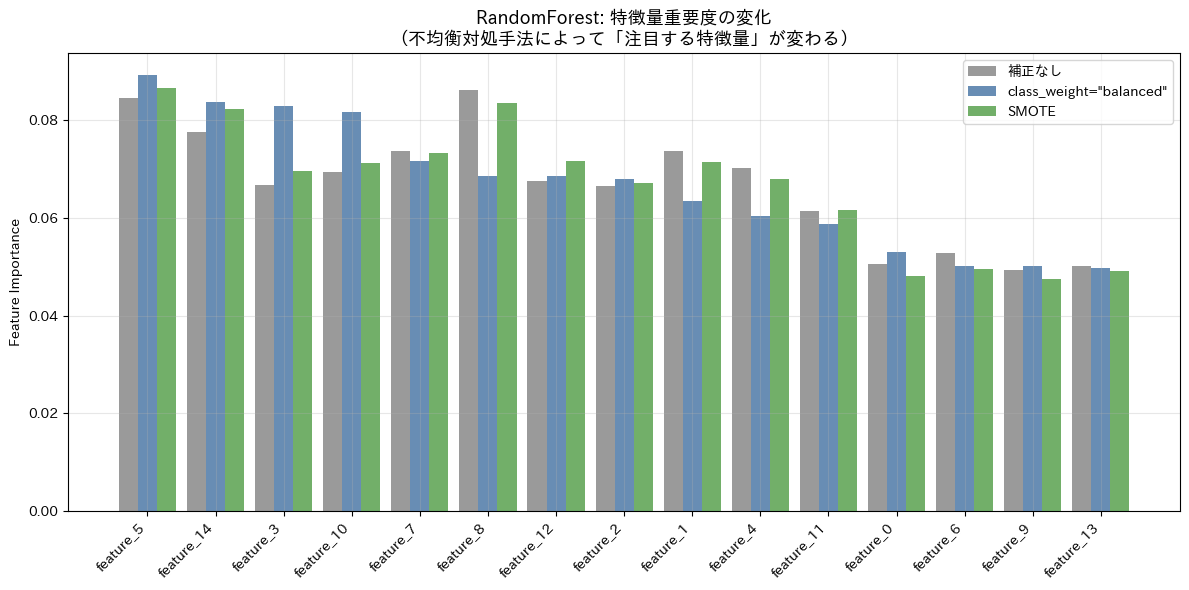

特徴量重要度は不均衡補正手法によって変化します。
balanced/SMOTEは少数クラスの識別に重要な特徴量を相対的に高く評価する傾向があります。


In [12]:
# RF の特徴量重要度を比較
# class_weight = balanced がどの特徴量の重要度に影響しているか確認

rf_no_bal = rf_configs["RF: 補正なし"][0]
rf_bal = rf_configs["RF: class_weight=balanced"][0]
rf_smote = rf_configs["RF: SMOTE + 補正なし"][0]

feature_names = [f"feature_{i}" for i in range(X_train_B.shape[1])]
imp_df = pd.DataFrame({
    "補正なし": rf_no_bal.feature_importances_,
    "balanced": rf_bal.feature_importances_,
    "SMOTE": rf_smote.feature_importances_,
}, index=feature_names).sort_values("balanced", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(imp_df))
w = 0.28
ax.bar(x - w,   imp_df['補正なし'], width=w, label='補正なし',   color='#888888', alpha=0.85)
ax.bar(x,       imp_df['balanced'], width=w, label='class_weight="balanced"', color='#4E79A7', alpha=0.85)
ax.bar(x + w,   imp_df['SMOTE'],    width=w, label='SMOTE',      color='#59A14F', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(imp_df.index, rotation=45, ha='right')
ax.set_title('RandomForest: 特徴量重要度の変化\n（不均衡対処手法によって「注目する特徴量」が変わる）',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Feature Importance')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('特徴量重要度は不均衡補正手法によって変化します。')
print('balanced/SMOTEは少数クラスの識別に重要な特徴量を相対的に高く評価する傾向があります。')

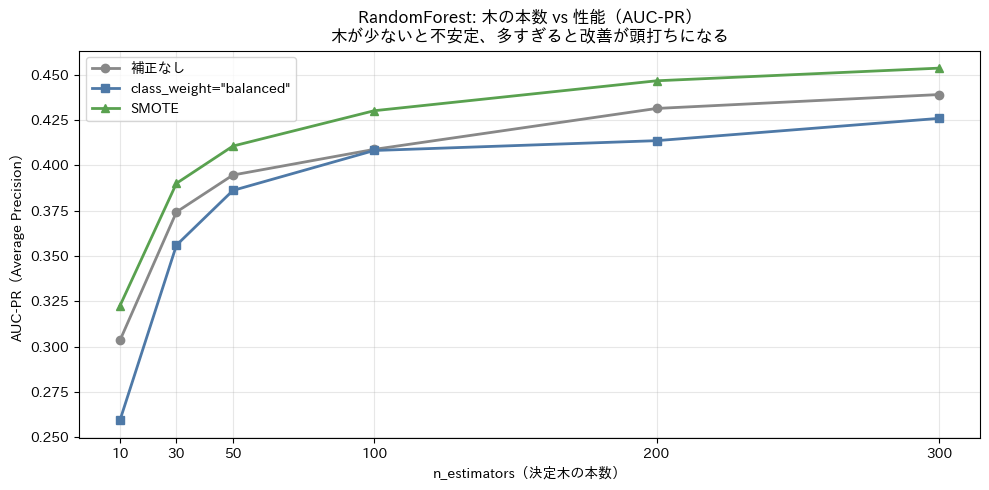

In [13]:
# n_estimators（木の本数）の感度分析
# 不均衡データでは木の本数をどのくらい増やすと性能が安定するか？

n_trees_list = [10, 30, 50, 100, 200, 300]
rf_no_bal_auc  = []
rf_bal_auc     = []
rf_smote_auc   = []

for n in n_trees_list:
    for results_list, X_tr, y_tr, cw in [
        (rf_no_bal_auc, X_train_B, y_train_B, None),
        (rf_bal_auc, X_train_B, y_train_B, 'balanced'),
        (rf_smote_auc, X_smote_B, y_smote_B, None),
    ]:
        rf = RandomForestClassifier(n_estimators=n, class_weight=cw, random_state=RANDOM_SEED, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        prob = rf.predict_proba(X_test_B)[:, 1]
        results_list.append(average_precision_score(y_test_B, prob))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_trees_list, rf_no_bal_auc,  marker='o', lw=2, color='#888888', label='補正なし')
ax.plot(n_trees_list, rf_bal_auc,     marker='s', lw=2, color='#4E79A7', label='class_weight="balanced"')
ax.plot(n_trees_list, rf_smote_auc,   marker='^', lw=2, color='#59A14F', label='SMOTE')
ax.set_xlabel('n_estimators（決定木の本数）')
ax.set_ylabel('AUC-PR（Average Precision）')
ax.set_title('RandomForest: 木の本数 vs 性能（AUC-PR）\n木が少ないと不安定、多すぎると改善が頭打ちになる',
             fontsize=12, fontweight='bold')
ax.set_xticks(n_trees_list)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_n_estimators_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Step4. GradientBoosting と scale_pos_weight の考え方

### GradientBoosting の仕組みと sample_weight

```
GradientBoosting（直列型）
  木1: データ全体を学習 → 残差（誤差）を計算
  木2: 残差を学習      → さらに残差を計算
  木3: 残差を学習      → ...
  最終予測 = 木1 + 木2 + 木3 + ...

不均衡データへの対処:
  sample_weight で各サンプルの「学習への貢献度」を調整。
  不正サンプルの weight を大きくすると、
  不正の残差を優先的に小さくしようと学習する。

XGBoost の scale_pos_weight:
  内部的には同じ sample_weight 操作。
  = n_negative / n_positive
```

In [14]:
# ── scale_pos_weight の計算と sample_weight への変換 ──

n_neg = (y_train_B == 0).sum()
n_pos = (y_train_B == 1).sum()
scale_pos_weight = n_neg / n_pos  # XGBoostと同じ計算式

print('【scale_pos_weight の計算】')
print(f'  n_negative (正常) = {n_neg:,}')
print(f'  n_positive (不正) = {n_pos:,}')
print(f'  scale_pos_weight  = {n_neg} / {n_pos} = {scale_pos_weight:.2f}')
print()
print('【sklearn GBM用 sample_weight への変換】')

# compute_sample_weight で同等の重みを計算
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_B)
w_neg_sample = sample_weights[y_train_B == 0][0]
w_pos_sample = sample_weights[y_train_B == 1][0]
print(f'  weight_normal (0) = {w_neg_sample:.4f}')
print(f'  weight_fraud  (1) = {w_pos_sample:.4f}')
print(f'  重み比率（不正/正常）= {w_pos_sample/w_neg_sample:.2f}倍')
print()
print('【カスタム重みの例 - ビジネスコストで設定】')
# 不正見逃し1件 = 顧客クレーム10件分 と仮定
business_cost_ratio = 10.0
custom_weights = np.where(y_train_B == 1, business_cost_ratio, 1.0)
print(f'  ビジネスコスト比 = {business_cost_ratio}')
print(f'  weight_normal = 1.0')
print(f'  weight_fraud  = {business_cost_ratio}')
print(f'  → これを clf.fit(X, y, sample_weight=custom_weights) として渡す')

【scale_pos_weight の計算】
  n_negative (正常) = 11,414
  n_positive (不正) = 586
  scale_pos_weight  = 11414 / 586 = 19.48

【sklearn GBM用 sample_weight への変換】
  weight_normal (0) = 0.5257
  weight_fraud  (1) = 10.2389
  重み比率（不正/正常）= 19.48倍

【カスタム重みの例 - ビジネスコストで設定】
  ビジネスコスト比 = 10.0
  weight_normal = 1.0
  weight_fraud  = 10.0
  → これを clf.fit(X, y, sample_weight=custom_weights) として渡す


In [15]:
# ── GBM系モデル × 3パターンの比較 ──

sample_weights_B    = compute_sample_weight('balanced', y=y_train_B)
sample_weights_smote = compute_sample_weight('balanced', y=y_smote_B)

gbm_configs = {
    'GBM: 補正なし': {
        'clf': GradientBoostingClassifier(
            n_estimators=100, 
            learning_rate=0.1,
            max_depth=4, 
            random_state=RANDOM_SEED
        ),
        'X': X_train_B, 'y': y_train_B, 'sw': None
    },
    'GBM: sample_weight (balanced)': {
        'clf': GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,                               
            max_depth=4, 
            random_state=RANDOM_SEED
        ),
        'X': X_train_B, 'y': y_train_B, 'sw': sample_weights_B
    },
    'GBM: SMOTE': {
        'clf': GradientBoostingClassifier(
            n_estimators=100, 
            learning_rate=0.1,
            max_depth=4, 
            random_state=RANDOM_SEED
        ),
        'X': X_smote_B, 'y': y_smote_B, 'sw': None
    },
    'GBM: SMOTE + sample_weight': {
        'clf': GradientBoostingClassifier(
            n_estimators=100, 
            learning_rate=0.1,
            max_depth=4, 
            random_state=RANDOM_SEED
        ),
        'X': X_smote_B, 'y': y_smote_B, 'sw': sample_weights_smote
    },
    'HistGBM: class_weight="balanced"': {
        'clf': HistGradientBoostingClassifier(
            class_weight='balanced',
            max_iter=100, 
            random_state=RANDOM_SEED
        ),
        'X': X_train_B, 'y': y_train_B, 'sw': None
    },
    'HistGBM: SMOTE': {
        'clf': HistGradientBoostingClassifier(
            max_iter=100, 
            random_state=RANDOM_SEED
        ),
        'X': X_smote_B, 'y': y_smote_B, 'sw': None
    },
}

gbm_results = {}
print('学習中...')
for name, cfg in gbm_configs.items():
    if cfg['sw'] is not None:
        cfg['clf'].fit(cfg['X'], cfg['y'], sample_weight=cfg['sw'])
    else:
        cfg['clf'].fit(cfg['X'], cfg['y'])
    prob = cfg['clf'].predict_proba(X_test_B)[:, 1]
    gbm_results[name] = {
        'prob': prob,
        'auc_roc': roc_auc_score(y_test_B, prob),
        'auc_pr':  average_precision_score(y_test_B, prob),
    }
    print(f'  {name:42s} AUC-ROC={gbm_results[name]["auc_roc"]:.4f}  AP={gbm_results[name]["auc_pr"]:.4f}')

学習中...
  GBM: 補正なし                                  AUC-ROC=0.7829  AP=0.3611
  GBM: sample_weight (balanced)              AUC-ROC=0.7651  AP=0.3743
  GBM: SMOTE                                 AUC-ROC=0.7642  AP=0.3998
  GBM: SMOTE + sample_weight                 AUC-ROC=0.7585  AP=0.3745
  HistGBM: class_weight="balanced"           AUC-ROC=0.7669  AP=0.3484
  HistGBM: SMOTE                             AUC-ROC=0.7692  AP=0.4228


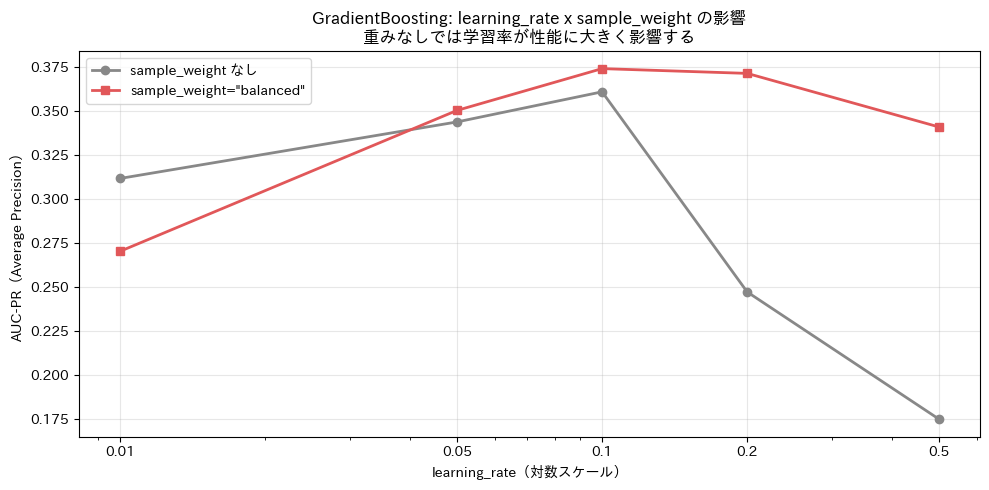

In [16]:
# ── GBM の learning_rate × sample_weight の影響 ──
# learning_rate が小さいほど慎重に学習するが、
# 不均衡データでは重みとの組み合わせが重要

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5]
gbm_no_weight_ap  = []
gbm_with_weight_ap = []

for lr in learning_rates:
    for ap_list, sw in [(gbm_no_weight_ap, None), (gbm_with_weight_ap, sample_weights_B)]:
        gbm = GradientBoostingClassifier(
            n_estimators=100, 
            learning_rate=lr,
            max_depth=4, 
            random_state=RANDOM_SEED
        )
        if sw is not None:
            gbm.fit(X_train_B, y_train_B, sample_weight=sw)
        else:
            gbm.fit(X_train_B, y_train_B)
        prob = gbm.predict_proba(X_test_B)[:, 1]
        ap_list.append(average_precision_score(y_test_B, prob))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    learning_rates, 
    gbm_no_weight_ap,   
    marker='o', 
    lw=2,
    color='#888888', 
    label='sample_weight なし'
)
ax.plot(
    learning_rates, 
    gbm_with_weight_ap, 
    marker='s', 
    lw=2,
    color='#E15759', 
    label='sample_weight="balanced"'
)
ax.set_xscale('log')
ax.set_xlabel('learning_rate（対数スケール）')
ax.set_ylabel('AUC-PR（Average Precision）')
ax.set_title(
    'GradientBoosting: learning_rate x sample_weight の影響\n'
    '重みなしでは学習率が性能に大きく影響する',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(learning_rates)
ax.set_xticklabels(learning_rates)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gbm_lr_vs_weight.png', dpi=150, bbox_inches='tight')
plt.show()

## Step5. 全モデル x 全手法 マトリクス実験

ここまでのモデル単体の実験をまとめ、2軸（モデル x 不均衡補正）のフルマトリクスで比較します。

In [17]:
# ── フルマトリクス実験の設計 ──

# モデル定義（class_weight なし版を基本にして、後で重みを差し込む）
MODEL_DEFS = {
    'LogReg':   lambda: LogisticRegression(max_iter=500, random_state=RANDOM_SEED),
    'RF':       lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
    'GBM':      lambda: GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=RANDOM_SEED),
    'HistGBM':  lambda: HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_SEED),
}

# 不均衡補正の設定
IMBALANCE_CONFIGS = {
    'NoResamp':     {'X': X_train_B, 'y': y_train_B, 'sw': None, 'cw': None},
    'SMOTE':        {'X': X_smote_B, 'y': y_smote_B, 'sw': None, 'cw': None},
    'ClassWeight':  {'X': X_train_B, 'y': y_train_B, 'sw': sample_weights_B, 'cw': 'balanced'},
    'SMOTE+Weight': {'X': X_smote_B, 'y': y_smote_B, 'sw': sample_weights_smote, 'cw': 'balanced'},
}

matrix_results = {}
print('実験実行中（全16パターン）...')
for (model_name, model_fn), (imb_name, imb_cfg) in product(
    MODEL_DEFS.items(), IMBALANCE_CONFIGS.items()
):
    clf = model_fn()

    # class_weight を持つモデルにのみ設定
    if imb_cfg['cw'] is not None and hasattr(clf, 'class_weight'):
        clf.set_params(class_weight=imb_cfg['cw'])

    # GBM系は sample_weight で fit
    sw = imb_cfg['sw'] if (model_name == 'GBM' and imb_name in ('ClassWeight', 'SMOTE+Weight')) else None

    if sw is not None:
        clf.fit(imb_cfg['X'], imb_cfg['y'], sample_weight=sw)
    else:
        clf.fit(imb_cfg['X'], imb_cfg['y'])

    prob = clf.predict_proba(X_test_B)[:, 1]
    matrix_results[(model_name, imb_name)] = {
        'auc_roc': roc_auc_score(y_test_B, prob),
        'auc_pr':  average_precision_score(y_test_B, prob),
        'prob': prob,
    }

print('\n完了!')
print(f'{"モデル":10s} x {"補正手法":15s}  AUC-ROC   AUC-PR')
print('-' * 55)
for (m, i), v in matrix_results.items():
    print(f'{m:10s} x {i:15s}  {v["auc_roc"]:.4f}    {v["auc_pr"]:.4f}')

実験実行中（全16パターン）...

完了!
モデル        x 補正手法             AUC-ROC   AUC-PR
-------------------------------------------------------
LogReg     x NoResamp         0.6805    0.1500
LogReg     x SMOTE            0.6887    0.1337
LogReg     x ClassWeight      0.6975    0.1222
LogReg     x SMOTE+Weight     0.6967    0.1206
RF         x NoResamp         0.7939    0.4315
RF         x SMOTE            0.8128    0.4468
RF         x ClassWeight      0.7863    0.4137
RF         x SMOTE+Weight     0.7925    0.4015
GBM        x NoResamp         0.7829    0.3611
GBM        x SMOTE            0.7642    0.3998
GBM        x ClassWeight      0.7651    0.3743
GBM        x SMOTE+Weight     0.7585    0.3745
HistGBM    x NoResamp         0.7911    0.4009
HistGBM    x SMOTE            0.7692    0.4228
HistGBM    x ClassWeight      0.7669    0.3484
HistGBM    x SMOTE+Weight     0.7578    0.3469


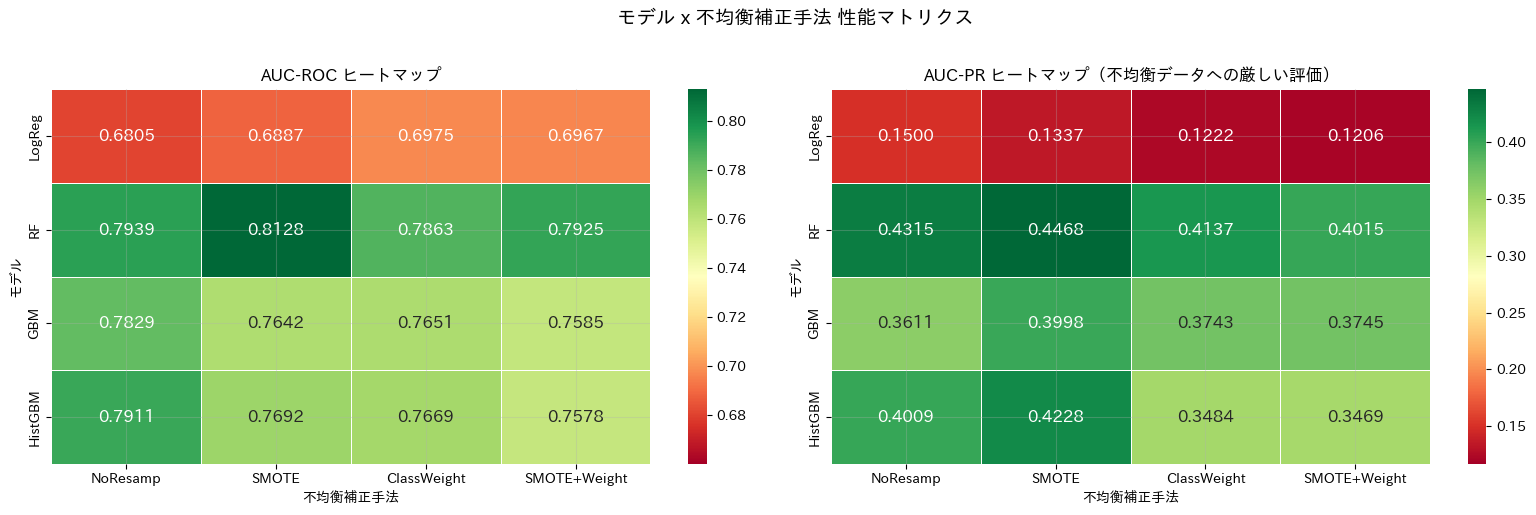

In [18]:
# ── ヒートマップ（モデル × 補正手法 × AUC-PR）──
model_names = list(MODEL_DEFS.keys())
imb_names   = list(IMBALANCE_CONFIGS.keys())

auc_roc_matrix = np.array([[matrix_results[(m,i)]['auc_roc'] for i in imb_names] for m in model_names])
auc_pr_matrix  = np.array([[matrix_results[(m,i)]['auc_pr']  for i in imb_names] for m in model_names])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title in zip(
    axes,
    [auc_roc_matrix, auc_pr_matrix],
    ['AUC-ROC ヒートマップ', 'AUC-PR ヒートマップ（不均衡データへの厳しい評価）']
):
    vmin = data.min() * 0.97
    sns.heatmap(
        data, annot=True, fmt='.4f',
        xticklabels=imb_names, yticklabels=model_names,
        cmap='RdYlGn', ax=ax, linewidths=0.5,
        vmin=vmin, vmax=data.max(),
        annot_kws={'size': 12}
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('不均衡補正手法')
    ax.set_ylabel('モデル')

plt.suptitle('モデル x 不均衡補正手法 性能マトリクス',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_imbalance_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

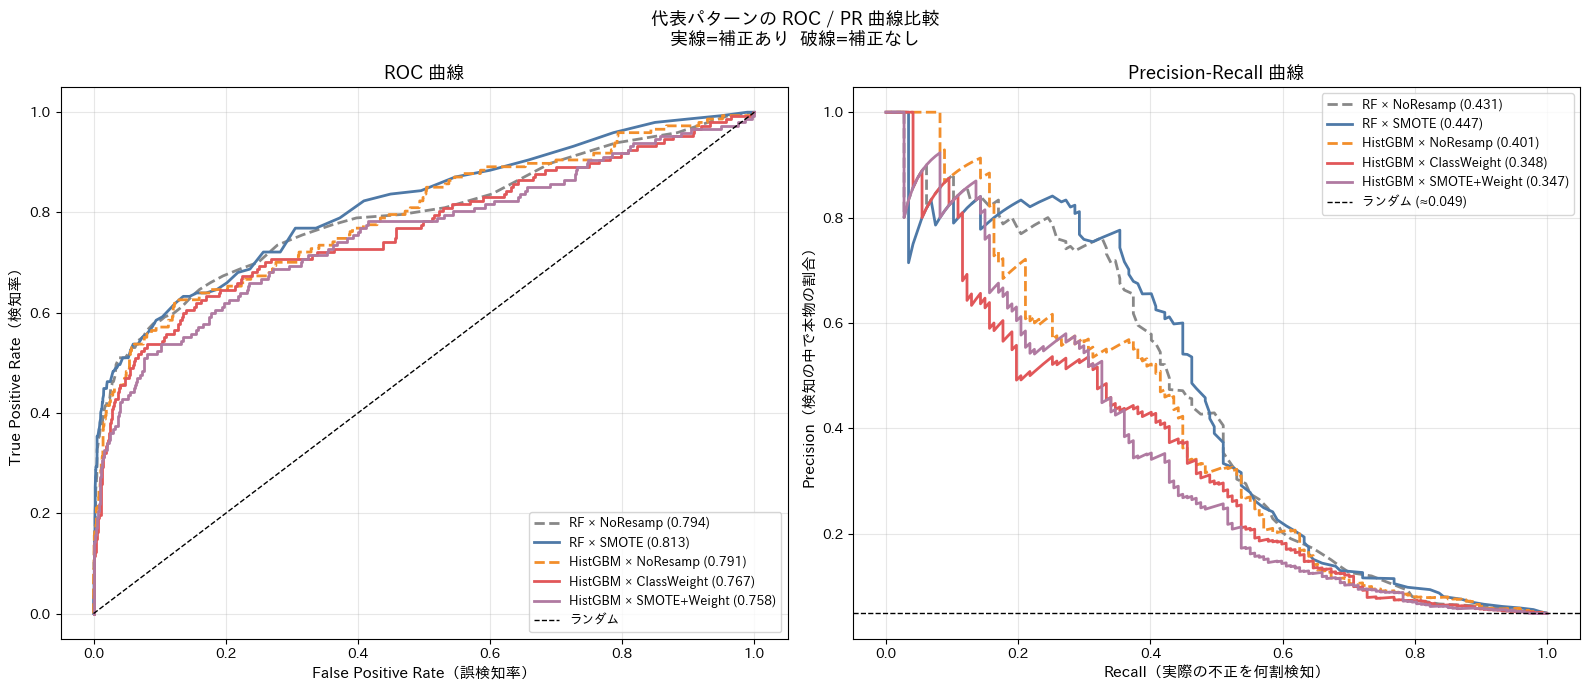

In [19]:
# ── ROC / PR 曲線を代表4パターンで比較 ──
# 「RF+補正なし」「RF+SMOTE」「HistGBM+補正なし」「HistGBM+ClassWeight」

focus_keys = [
    ('RF',      'NoResamp',    '#888888', '--'),
    ('RF',      'SMOTE',       '#4E79A7', '-'),
    ('HistGBM', 'NoResamp',    '#F28E2B', '--'),
    ('HistGBM', 'ClassWeight', '#E15759', '-'),
    ('HistGBM', 'SMOTE+Weight','#B07AA1', '-'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for model_name, imb_name, color, ls in focus_keys:
    prob  = matrix_results[(model_name, imb_name)]['prob']
    label = f'{model_name} × {imb_name}'
    auc   = matrix_results[(model_name, imb_name)]['auc_roc']
    ap    = matrix_results[(model_name, imb_name)]['auc_pr']

    fpr, tpr, _    = roc_curve(y_test_B, prob)
    prec, rec, _   = precision_recall_curve(y_test_B, prob)

    axes[0].plot(fpr, tpr, color=color, ls=ls, lw=2,
                 label=f'{label} ({auc:.3f})')
    axes[1].plot(rec, prec, color=color, ls=ls, lw=2,
                 label=f'{label} ({ap:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1,label='ランダム')
axes[0].set_xlabel('False Positive Rate（誤検知率）', fontsize=11)
axes[0].set_ylabel('True Positive Rate（検知率）', fontsize=11)
axes[0].set_title('ROC 曲線', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')

axes[1].axhline(y_test_B.mean(), color='k', ls='--', lw=1,
                label=f'ランダム (≈{y_test_B.mean():.3f})')
axes[1].set_xlabel('Recall（実際の不正を何割検知）', fontsize=11)
axes[1].set_ylabel('Precision（検知の中で本物の割合）', fontsize=11)
axes[1].set_title('Precision-Recall 曲線', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')

plt.suptitle('代表パターンの ROC / PR 曲線比較\n実線=補正あり  破線=補正なし',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step6. 交差検証（Cross Validation）で信頼性を確認

1回の train / test 分割では結果が「たまたま良かった / 悪かった」可能性があります。<br>
交差検証で 平均 と 分散 を確認し、安定した比較を行います。

```
StratifiedKFold（層化K分割）
  ├── Fold 1: [Train─────────────] [Val]
  ├── Fold 2: [Train────────][Val][────]
  ├── Fold 3: [Train────][Val][────────]
  └── ...（K=5）
  → 各Foldのスコア平均を「真の性能」として扱う
  → 不均衡データは必ず StratifiedKFold（各FoldでFraud率を均等に保つ）
```

In [30]:
for train, test in skf.split(X, y):
    print(f"Train: {len(train)}")
    print(f"Test: {len(test)}")

Train: 9600
Test: 2400
Train: 9600
Test: 2400
Train: 9600
Test: 2400
Train: 9600
Test: 2400
Train: 9600
Test: 2400


In [40]:
from sklearn.metrics import make_scorer

# 交差検証用スコアラー
ap_scorer  = make_scorer(average_precision_score, needs_proba=True)
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# 代表的な4パターンで交差検証
cv_configs = {
    'RF: 補正なし': (
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
        X_train_B, y_train_B
    ),
    'RF: class_weight=balanced': (
        RandomForestClassifier(
            n_estimators=100, 
            class_weight='balanced',
            random_state=RANDOM_SEED, 
            n_jobs=-1
        ),
        X_train_B, y_train_B
    ),
    'HistGBM: 補正なし': (
        HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_SEED),
        X_train_B, y_train_B
    ),
    'HistGBM: class_weight=balanced': (
        HistGradientBoostingClassifier(
            class_weight='balanced', 
            max_iter=100,
            random_state=RANDOM_SEED
        ),
        X_train_B, y_train_B
    ),
}

cv_results = {}
print('交差検証中（5-Fold）...')
for name, (clf, X, y) in cv_configs.items():
    scores = {}
    for i, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        clf.fit(X[train_idx], y[train_idx])
        proba = clf.predict_proba(X[test_idx])[:,1]
        scores[f"{name}{i}"] = {
            "test_auc_pr": average_precision_score(y[test_idx], proba),
            "test_auc_roc": roc_auc_score(y[test_idx], proba),
        }
    cv_results[name] = {
        'auc_pr_scores':  scores['test_auc_pr'],
        'auc_roc_scores': scores['test_auc_roc'],
        'auc_pr_mean':    scores['test_auc_pr'].mean(),
        'auc_pr_std':     scores['test_auc_pr'].std(),
        'auc_roc_mean':   scores['test_auc_roc'].mean(),
    }
    print(f'  {name:38s} AP={cv_results[name]["auc_pr_mean"]:.4f} ± {cv_results[name]["auc_pr_std"]:.4f}')

交差検証中（5-Fold）...


KeyError: 'test_auc_pr'

In [39]:
cv_results
scores

{'HistGBM: class_weight=balanced1': {'test_auc_pr': 0.37091802989742495,
  'test_auc_roc': 0.7115468850028641},
 'HistGBM: class_weight=balanced2': {'test_auc_pr': 0.44848969872971206,
  'test_auc_roc': 0.7795523209452251},
 'HistGBM: class_weight=balanced3': {'test_auc_pr': 0.4587271248583542,
  'test_auc_roc': 0.7826746184170625},
 'HistGBM: class_weight=balanced4': {'test_auc_pr': 0.38653148808157933,
  'test_auc_roc': 0.7301721007371468},
 'HistGBM: class_weight=balanced5': {'test_auc_pr': 0.34562265339314313,
  'test_auc_roc': 0.712566288863471}}

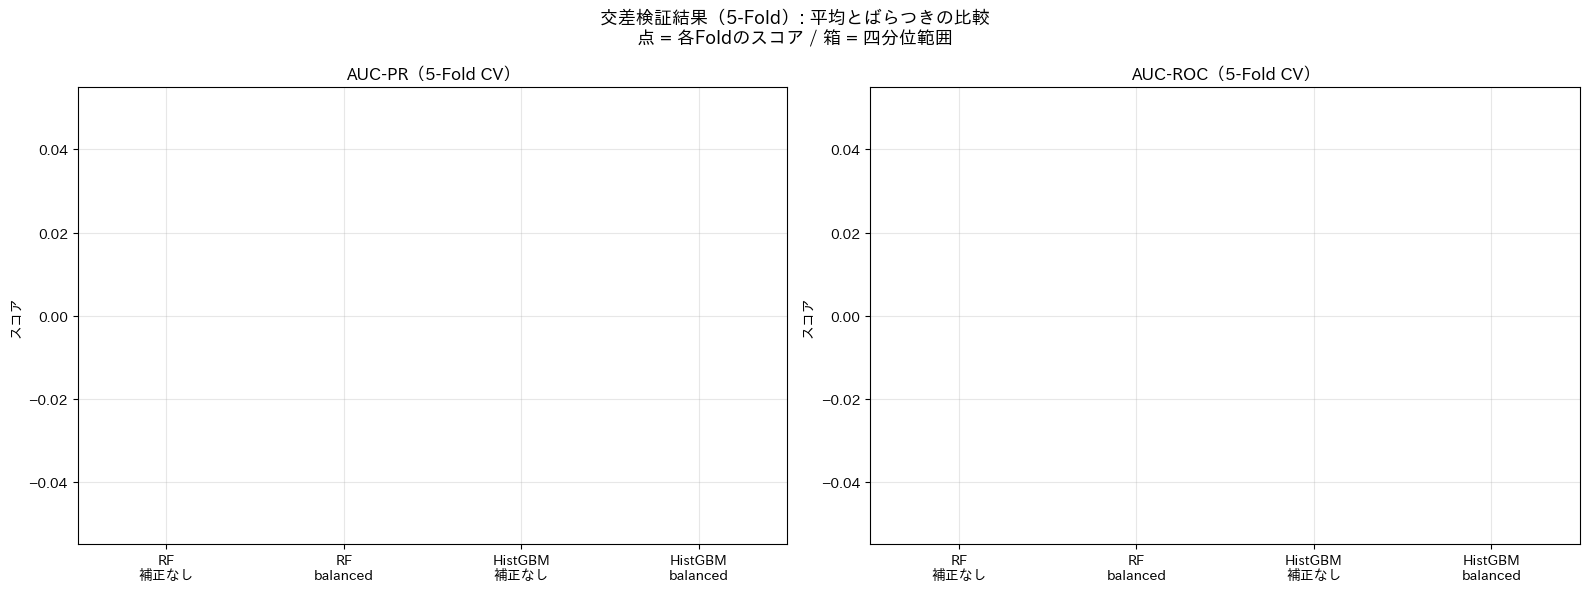


【読み方ポイント】
  ・平均スコアが高いモデルを選ぶのは基本
  ・ばらつき（箱の幅）が大きいと本番でも性能が不安定になりやすい
  ・平均とばらつきのトレードオフで最終的なモデルを選択する


In [22]:
# ── CV結果のバイオリンプロット ──
# 平均だけでなく「ばらつき（分散）」も確認する

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_cv = ['#888888', '#4E79A7', '#F28E2B', '#E15759']

for ax, metric_key, title in [
    (axes[0], 'auc_pr_scores',  'AUC-PR（5-Fold CV）'),
    (axes[1], 'auc_roc_scores', 'AUC-ROC（5-Fold CV）'),
]:
    names  = list(cv_results.keys())
    data   = [cv_results[n][metric_key] for n in names]
    short  = ['RF\n補正なし', 'RF\nbalanced', 'HistGBM\n補正なし', 'HistGBM\nbalanced']

    bp = ax.boxplot(
        data, 
        patch_artist=True, 
        widths=0.5,
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], colors_cv):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # 各点をオーバーレイ
    for i, (d, c) in enumerate(zip(data, colors_cv), 1):
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(d))
        ax.scatter(
            np.full(len(d), i) + jitter, d, 
            color=c,
            s=50, 
            zorder=5, 
            alpha=0.9
        )

    ax.set_xticks(range(1, len(names)+1))
    ax.set_xticklabels(short, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('スコア')

plt.suptitle('交差検証結果（5-Fold）: 平均とばらつきの比較\n'
             '点 = 各Foldのスコア / 箱 = 四分位範囲',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n【読み方ポイント】')
print('  ・平均スコアが高いモデルを選ぶのは基本')
print('  ・ばらつき（箱の幅）が大きいと本番でも性能が不安定になりやすい')
print('  ・平均とばらつきのトレードオフで最終的なモデルを選択する')